
فصل اول: سیگنال، ریاضیات و ابزارها

درس 4: 

# 🧩 MFCC اثر انگشت صوتی: شبیه‌سازی گوش انسان با 

### 1️⃣ نصب و وارد کردن کتابخانه‌ها

In [ ]:
%pip install -v -i https://mirror-pypi.runflare.com/simple librosa soundfile matplotlib sounddevice numpy --trusted-host mirror-pypi.runflare.com

In [2]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf

### 2️⃣ ضبط دو کلمه‌ی متفاوت برای انگشت‌نگاری!

In [3]:
duration = 2  
sr = 44100

# ضبط کلمه اول
print(" 🎙️ 'کلمه اول: لطفا بگویید 'سیب")
rec_word1 = sd.rec(int(sr * duration), samplerate=sr, channels=1)
sd.wait()
sf.write("word1.wav", rec_word1, sr)
print(" .کلمه اول ذخیره شد.")

# ضبط کلمه دوم
print(" 🎙️ 'کلمه دوم: لطفا بگویید 'پایتون")
rec_word2 = sd.rec(int(sr * duration), samplerate=sr, channels=1)
sd.wait()
sf.write("word2.wav", rec_word2, sr)
print(" .کلمه دوم ذخیره شد.")

 🎙️ 'کلمه اول: لطفا بگویید 'سیب
 .کلمه اول ذخیره شد.
 🎙️ 'کلمه دوم: لطفا بگویید 'پایتون
 .کلمه دوم ذخیره شد.


### 3️⃣ درک شهودی مقیاس مل

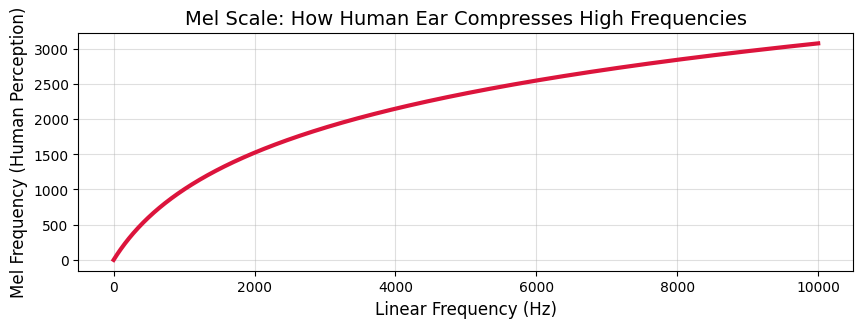

In [4]:

freqs_hz = np.linspace(0, 10000, 1000)

mels = 2595 * np.log10(1 + freqs_hz / 700)

plt.figure(figsize=(10, 5))
plt.plot(freqs_hz, mels, color='crimson', linewidth=3)
plt.title("Mel Scale: How Human Ear Compresses High Frequencies", fontsize=14)
plt.xlabel("Linear Frequency (Hz)", fontsize=12)
plt.ylabel("Mel Frequency (Human Perception)", fontsize=12)
plt.grid(True, alpha=0.4)

plt.gca().set_aspect(1)
plt.show()


### 4️⃣ از اسپکتروگرام تا مقیاس مل 


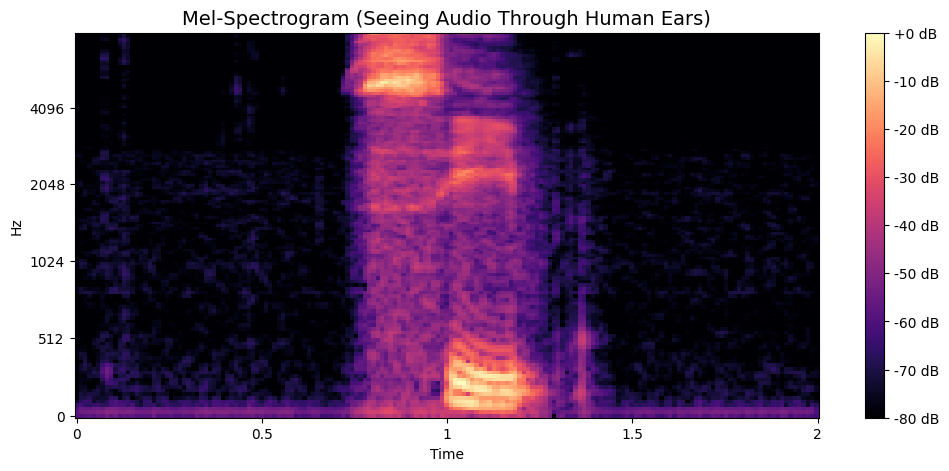

In [5]:
y1, sr = librosa.load("word1.wav", sr=None)

S_mel = librosa.feature.melspectrogram(y=y1, sr=sr, n_mels=128, fmax=8000)

S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(S_mel_db, x_axis='time', y_axis='mel', sr=sr, fmax=8000, cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-Spectrogram (Seeing Audio Through Human Ears)", fontsize=14)
plt.show()

### 5️⃣ استخراج ۱۳ ویژگی جادویی: MFCC


In [6]:

# این ۱۳ سطر، نمایانگر فیزیک مجرای صوتی شما هنگام ادای این کلمه است
mfccs_word1 = librosa.feature.mfcc(y=y1, sr=sr, n_mfcc=13)


print(f"شکل ماتریس برای کلمه اول: {mfccs_word1.shape}")

شکل ماتریس برای کلمه اول: (13, 173)


### 6️⃣ رسم Heatmap اثر انگشت

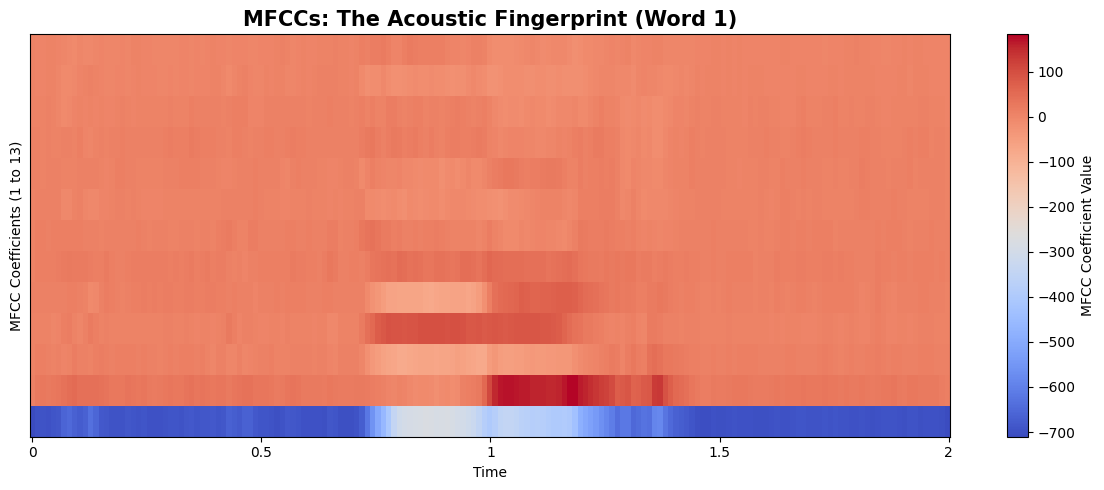

In [7]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(mfccs_word1, x_axis='time', sr=sr, cmap='coolwarm')

plt.colorbar(label='MFCC Coefficient Value')
plt.title("MFCCs: The Acoustic Fingerprint (Word 1)", fontsize=15, fontweight='bold')
plt.ylabel("MFCC Coefficients (1 to 13)")
plt.xlabel("Time")
plt.tight_layout()
plt.show()

### 7️⃣ مقایسه نهایی: هوش مصنوعی چطور کلمات را می‌فهمد؟

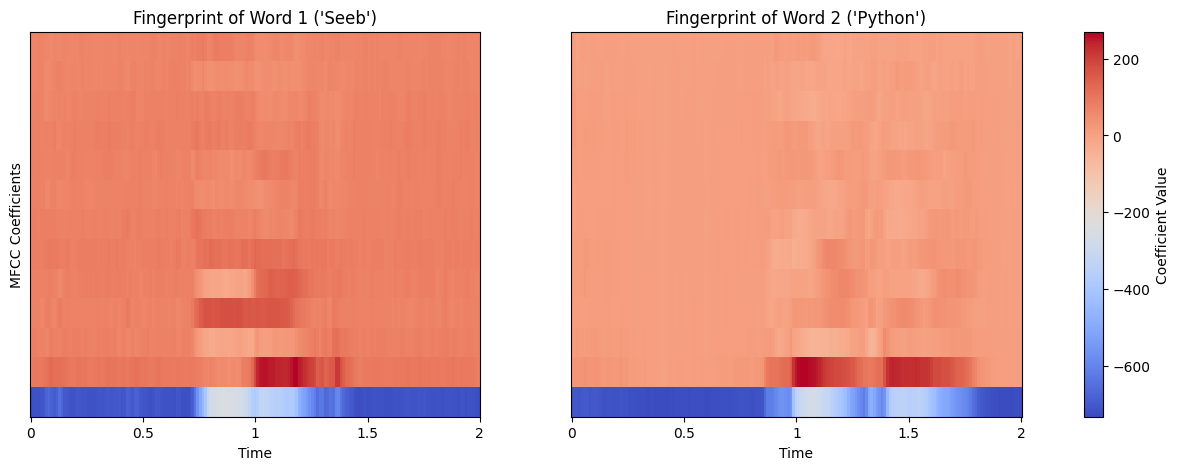

In [8]:
# بارگذاری و استخراج MFCC کلمه دوم
y2, sr = librosa.load("word2.wav", sr=None)
mfccs_word2 = librosa.feature.mfcc(y=y2, sr=sr, n_mfcc=13)

# رسم مقایسه‌ای
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 5), sharey=True)

librosa.display.specshow(mfccs_word1, x_axis='time', sr=sr, ax=ax[0], cmap='coolwarm')
ax[0].set(title="Fingerprint of Word 1 ('Seeb')", ylabel="MFCC Coefficients")

img = librosa.display.specshow(mfccs_word2, x_axis='time', sr=sr, ax=ax[1], cmap='coolwarm')
ax[1].set(title="Fingerprint of Word 2 ('Python')")

fig.colorbar(img, ax=ax, label='Coefficient Value')
plt.show()


### 🏁 جمع‌بندی




: امروز یاد گرفتیم که
- گوش ما یک گیرنده‌ی خطی نیست و **مقیاس مل** ریاضیات را با بیولوژی کوک می‌کند.
-  صدای خام را از فیلترهای شنوایی ما عبور می‌دهد.
- **کپستروم** اطلاعات اضافی را دور می‌ریزند و عصاره‌ی خالص صدا (ساختار حنجره) را در ۱۳ عدد استخراج می‌کنند.
- به صورت بصری ثابت کردیم که هر کلمه، **اثر انگشت صوتی** کاملاً منحصر‌به‌فردی دارد.

**آماده‌اید؟**  
در فصل بعدی، قرار است این ۱۳ ویژگی طلایی را به الگوریتم‌های یادگیری ماشین تزریق کنیم تا کامپیوتر بتواند "احساسات" ما را از روی صدایمان حدس بزند! 
